# APR as a 3D Point Cloud

Each APR particle occupies a cubic cell whose side-length is `2^(level_max - level)` pixels.  
Its **centroid** is the centre of that cell in pixel space, and its **intensity** is the mean of the original pixel values inside the cell.

This notebook extracts and visualises the full 3D point cloud, showing how the adaptive resolution distributes particles across the volume.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pyapr

print(f"pyapr {pyapr.__version__}")

pyapr 1.0.8.dev1+g545b817f4


## 2. Synthetic 3D image

Gaussian blobs on a noisy background — mimics fluorescent beads in a volume.

shape=(64, 64, 64)  dtype=uint16  min=0  max=65535


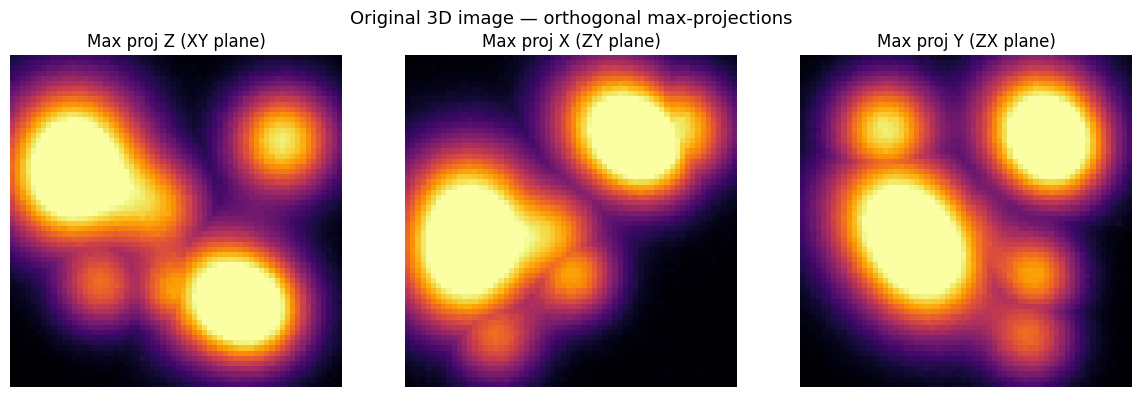

In [2]:
def make_3d_image(shape=(64, 64, 64), n_blobs=8, seed=0):
    rng = np.random.default_rng(seed)
    Z, X, Y = shape
    img = np.zeros(shape, dtype=np.float32)
    zz, xx, yy = np.mgrid[:Z, :X, :Y]
    for _ in range(n_blobs):
        cz = rng.integers(8, Z - 8)
        cx = rng.integers(8, X - 8)
        cy = rng.integers(8, Y - 8)
        sigma = rng.uniform(3, 10)
        amp   = rng.uniform(0.6, 1.0)
        img  += amp * np.exp(-((zz-cz)**2 + (xx-cx)**2 + (yy-cy)**2) / (2*sigma**2))
    img += rng.normal(0.02, 0.008, shape)
    img  = np.clip(img, 0, 1)
    return (img * 65535).astype(np.uint16)

img = make_3d_image(shape=(64, 64, 64), n_blobs=8, seed=42)
print(f"shape={img.shape}  dtype={img.dtype}  min={img.min()}  max={img.max()}")

# Show three orthogonal max-projections of the original image
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, proj, label in zip(
    axes,
    [img.max(axis=0), img.max(axis=1), img.max(axis=2)],
    ['Max proj Z (XY plane)', 'Max proj X (ZY plane)', 'Max proj Y (ZX plane)']
):
    ax.imshow(proj, cmap='inferno')
    ax.set_title(label)
    ax.axis('off')
plt.suptitle('Original 3D image — orthogonal max-projections', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Convert to APR

In [3]:
apr, parts = pyapr.converter.get_apr(img)

it = apr.iterator()
level_min = it.level_min()
level_max = it.level_max()

print(f"Total particles    : {apr.total_number_particles():,}")
print(f"Total pixels       : {img.size:,}")
print(f"Compression ratio  : {img.size / apr.total_number_particles():.2f}x")
print(f"Level range        : [{level_min}, {level_max}]")
print(f"APR shape (z,x,y)  : {apr.shape()}")

Total particles    : 138,489
Total pixels       : 262,144
Compression ratio  : 1.89x
Level range        : [1, 6]
APR shape (z,x,y)  : (64, 64, 64)


## 4. Extract the 3D point cloud

For each particle at `(level, z, x, y_idx)` on the APR multi-resolution grid:

```
cell_size          = 2 ** (level_max - level)      # side-length in pixels
centroid_z         = (z     + 0.5) * cell_size
centroid_x         = (x     + 0.5) * cell_size
centroid_y         = (y_idx + 0.5) * cell_size
```

The result is a table with one row per particle and columns:
`[z, x, y, intensity, cell_size, level]`

In [4]:
def apr_to_pointcloud_3d(apr, parts):
    """Extract all APR particles as a structured numpy array.

    Returns
    -------
    pc : np.ndarray, shape (N, 6), float32
        Columns: z_center, x_center, y_center, intensity, cell_size, level
    """
    it = apr.iterator()
    lmax = it.level_max()
    rows = []

    for level in range(it.level_min(), lmax + 1):
        cs = 2 ** (lmax - level)          # cell side-length in pixels
        for z in range(it.z_num(level)):
            for x in range(it.x_num(level)):
                for idx in range(it.begin(level, z, x), it.end()):
                    y = it.y(idx)
                    rows.append([
                        (z + 0.5) * cs,   # z centroid
                        (x + 0.5) * cs,   # x centroid
                        (y + 0.5) * cs,   # y centroid
                        float(parts[idx]),# intensity
                        float(cs),        # cell side-length
                        float(level),     # resolution level
                    ])

    return np.array(rows, dtype=np.float32)


print("Extracting point cloud …")
pc = apr_to_pointcloud_3d(apr, parts)

# Named views into each column
pz, px, py       = pc[:, 0], pc[:, 1], pc[:, 2]
intensity         = pc[:, 3]
cell_size         = pc[:, 4]
level             = pc[:, 5].astype(int)

print(f"Point cloud shape  : {pc.shape}   (N_particles, 6)")
print(f"Columns            : z_center, x_center, y_center, intensity, cell_size, level")
print()
print(f"z range   : [{pz.min():.1f}, {pz.max():.1f}] px")
print(f"x range   : [{px.min():.1f}, {px.max():.1f}] px")
print(f"y range   : [{py.min():.1f}, {py.max():.1f}] px")
print(f"intensity : [{intensity.min():.0f}, {intensity.max():.0f}]")
print(f"cell sizes: {np.unique(cell_size).astype(int).tolist()} px")
print(f"levels    : {np.unique(level).tolist()}")

Extracting point cloud …
Point cloud shape  : (138489, 6)   (N_particles, 6)
Columns            : z_center, x_center, y_center, intensity, cell_size, level

z range   : [0.5, 63.5] px
x range   : [0.5, 63.5] px
y range   : [0.5, 63.5] px
intensity : [799, 65535]
cell sizes: [1, 2, 4, 8] px
levels    : [3, 4, 5, 6]


## 5. Particle distribution per level

The APR places fine particles (small cells) in signal-rich regions and coarse particles (large cells) in the background.

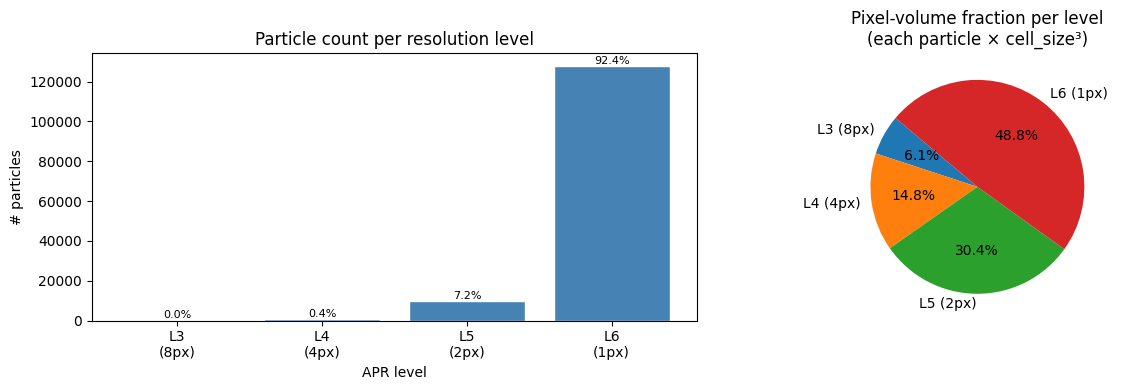

 Level  cell (px)  # particles  % particles  % pixel vol
--------------------------------------------------------
     3          8           31         0.0%         6.1%
     4          4          606         0.4%        14.8%
     5          2        9,948         7.2%        30.4%
     6          1      127,904        92.4%        48.8%


In [5]:
unique_levels, counts = np.unique(level, return_counts=True)
cell_sizes_per_level  = [int(2 ** (level_max - l)) for l in unique_levels]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: particle count per level
bars = axes[0].bar(unique_levels, counts, color='steelblue', edgecolor='white')
axes[0].set_xlabel('APR level')
axes[0].set_ylabel('# particles')
axes[0].set_title('Particle count per resolution level')
axes[0].set_xticks(unique_levels)
axes[0].set_xticklabels([f'L{l}\n({cs}px)' for l, cs in zip(unique_levels, cell_sizes_per_level)])
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{100*c/len(level):.1f}%', ha='center', va='bottom', fontsize=8)

# Pie: fraction of pixels represented by each level
pixel_equiv = counts * np.array([cs**3 for cs in cell_sizes_per_level])
axes[1].pie(
    pixel_equiv,
    labels=[f'L{l} ({cs}px)' for l, cs in zip(unique_levels, cell_sizes_per_level)],
    autopct='%1.1f%%',
    startangle=140,
)
axes[1].set_title('Pixel-volume fraction per level\n(each particle × cell_size³)')

plt.tight_layout()
plt.show()

print(f"{'Level':>6} {'cell (px)':>10} {'# particles':>12} {'% particles':>12} {'% pixel vol':>12}")
print('-' * 56)
for l, cs, c, pv in zip(unique_levels, cell_sizes_per_level, counts, pixel_equiv):
    print(f"{l:>6} {cs:>10} {c:>12,} {100*c/len(level):>11.1f}% {100*pv/pixel_equiv.sum():>11.1f}%")

## 6. 3D scatter — coloured by intensity

Marker size scales with `cell_size` so you can see the multi-resolution structure.

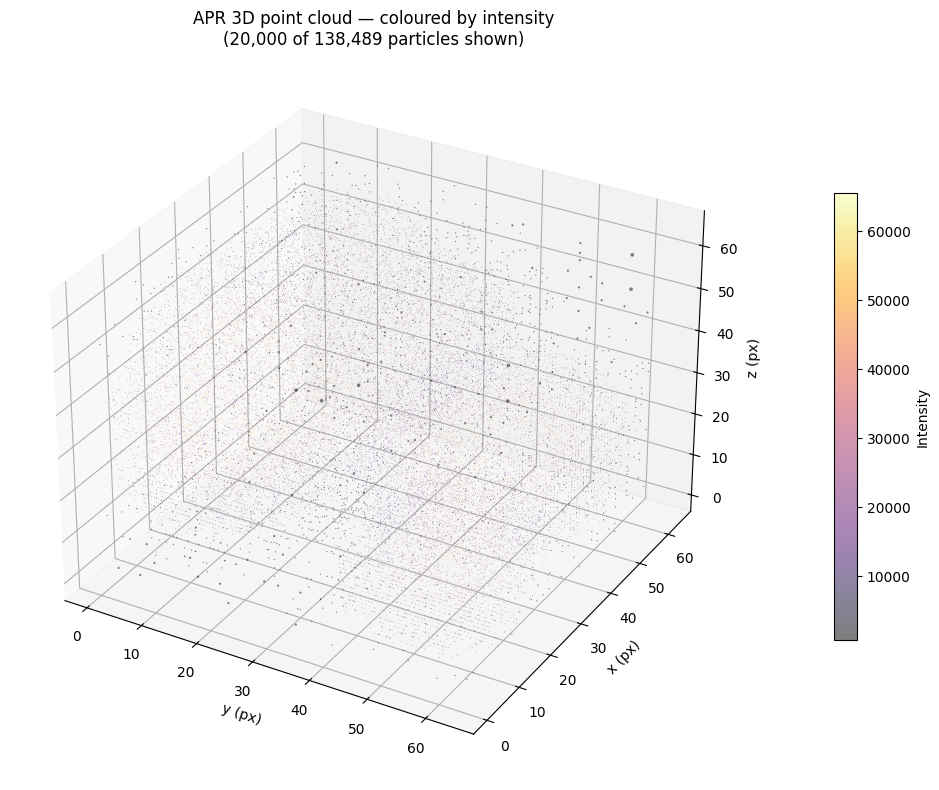

In [6]:
# Subsample for a readable scatter (matplotlib 3D gets slow with >50k points)
rng = np.random.default_rng(0)
n_show = min(len(pc), 20_000)
idx = rng.choice(len(pc), n_show, replace=False)

sz  = cell_size[idx] ** 1.5 * 0.3   # marker area
col = intensity[idx]

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(
    py[idx], px[idx], pz[idx],
    c=col, cmap='inferno',
    s=sz, alpha=0.5, linewidths=0,
)
ax.set_xlabel('y (px)'); ax.set_ylabel('x (px)'); ax.set_zlabel('z (px)')
ax.set_title(f'APR 3D point cloud — coloured by intensity\n({n_show:,} of {len(pc):,} particles shown)')
plt.colorbar(sc, ax=ax, label='Intensity', shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

## 7. 3D scatter — coloured by resolution level

Fine particles (high level, small cell) appear near signal; coarse particles (low level, large cell) fill the background.

/var/folders/v_/7mhfqnhs3d76987qq5hjcz2c0000gn/T/ipykernel_62662/1209812829.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lvl = plt.cm.get_cmap('plasma', len(unique_levels))


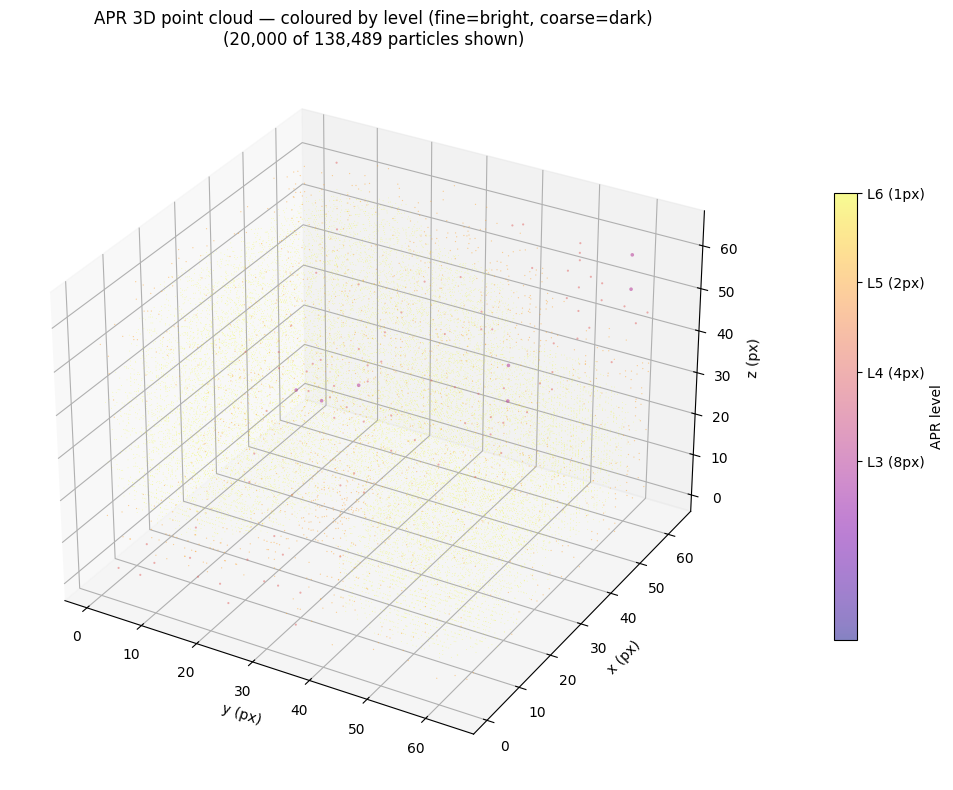

In [7]:
cmap_lvl = plt.cm.get_cmap('plasma', len(unique_levels))
level_norm = Normalize(vmin=level_min, vmax=level_max)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    py[idx], px[idx], pz[idx],
    c=level[idx], cmap='plasma',
    norm=level_norm,
    s=sz, alpha=0.5, linewidths=0,
)
ax.set_xlabel('y (px)'); ax.set_ylabel('x (px)'); ax.set_zlabel('z (px)')
ax.set_title(f'APR 3D point cloud — coloured by level (fine=bright, coarse=dark)\n({n_show:,} of {len(pc):,} particles shown)')
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('APR level')
cbar.set_ticks(unique_levels)
cbar.set_ticklabels([f'L{l} ({2**(level_max-l)}px)' for l in unique_levels])
plt.tight_layout()
plt.show()

## 8. Orthogonal projections — original vs APR point cloud

Compare the three max-projections of the original image with a 2D scatter of particle centroids projected onto the same planes.

/var/folders/v_/7mhfqnhs3d76987qq5hjcz2c0000gn/T/ipykernel_62662/4021208066.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


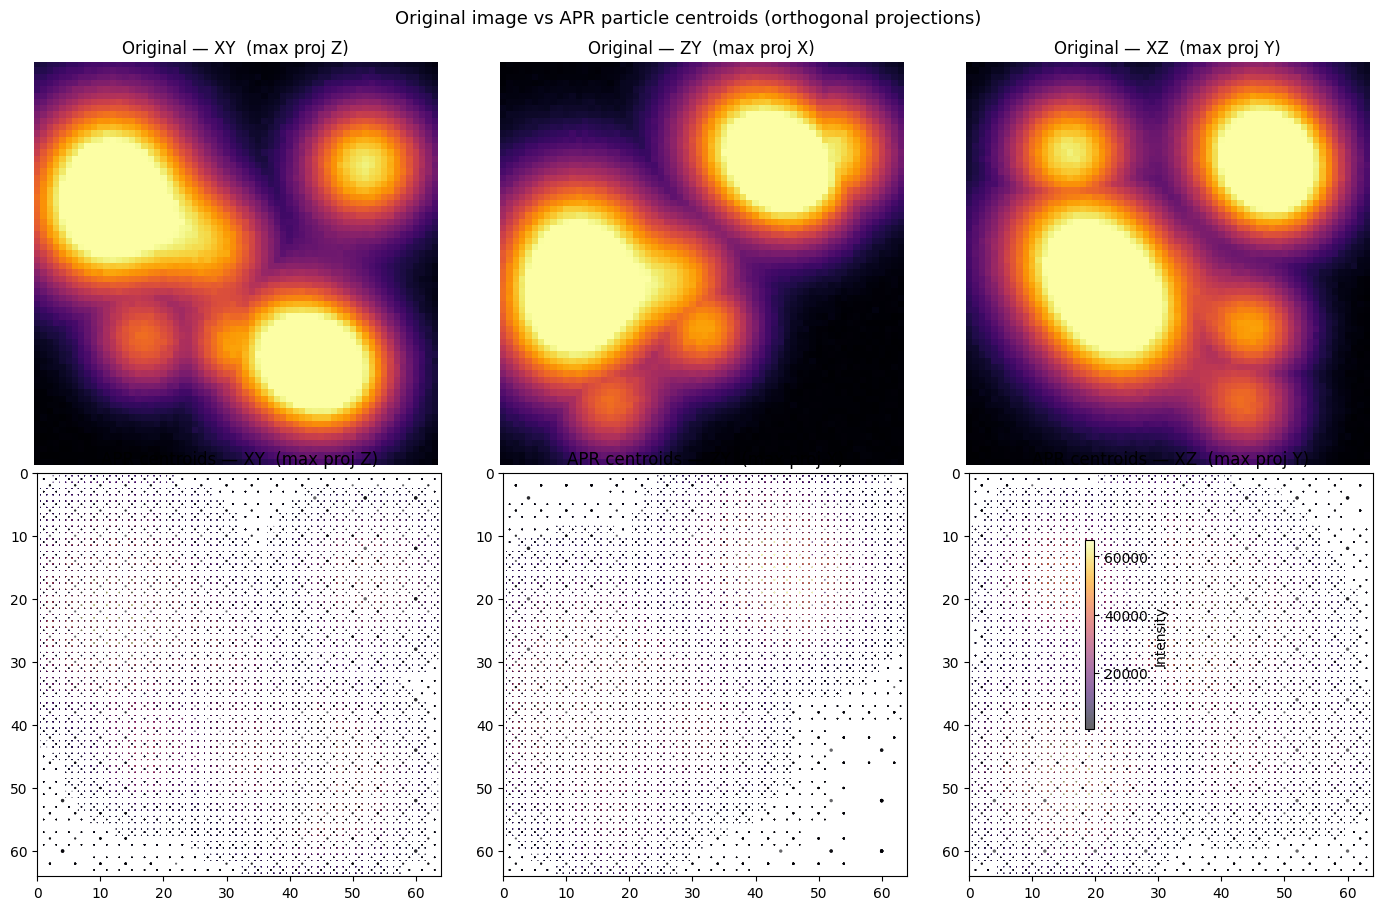

In [8]:
Z, X, Y = img.shape
norm_i   = Normalize(vmin=intensity.min(), vmax=intensity.max())
marker_s = cell_size ** 1.3 * 0.4

planes = [
    # (title, img_proj, horiz_coord, vert_coord, xlim, ylim)
    ('XY  (max proj Z)', img.max(axis=0), py,  px,  (0, Y), (X, 0)),
    ('ZY  (max proj X)', img.max(axis=1), py,  pz,  (0, Y), (Z, 0)),
    ('XZ  (max proj Y)', img.max(axis=2), pz,  px,  (0, Z), (X, 0)),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, (title, proj, h, v, xlim, ylim) in enumerate(planes):
    axes[0, col].imshow(proj, cmap='inferno', origin='upper')
    axes[0, col].set_title(f'Original — {title}')
    axes[0, col].axis('off')

    sc = axes[1, col].scatter(
        h, v, c=intensity, cmap='inferno', norm=norm_i,
        s=marker_s, alpha=0.6, linewidths=0
    )
    axes[1, col].set_xlim(*xlim)
    axes[1, col].set_ylim(*ylim)
    axes[1, col].set_aspect('equal')
    axes[1, col].set_title(f'APR centroids — {title}')

plt.colorbar(sc, ax=axes[1, :].tolist(), label='Intensity', shrink=0.6)
plt.suptitle('Original image vs APR particle centroids (orthogonal projections)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Zoom into a slab — drawing particles as cubes (squares in 2D)

Take a thin slab in Z and draw each particle's cross-section as a square whose side equals `cell_size`.

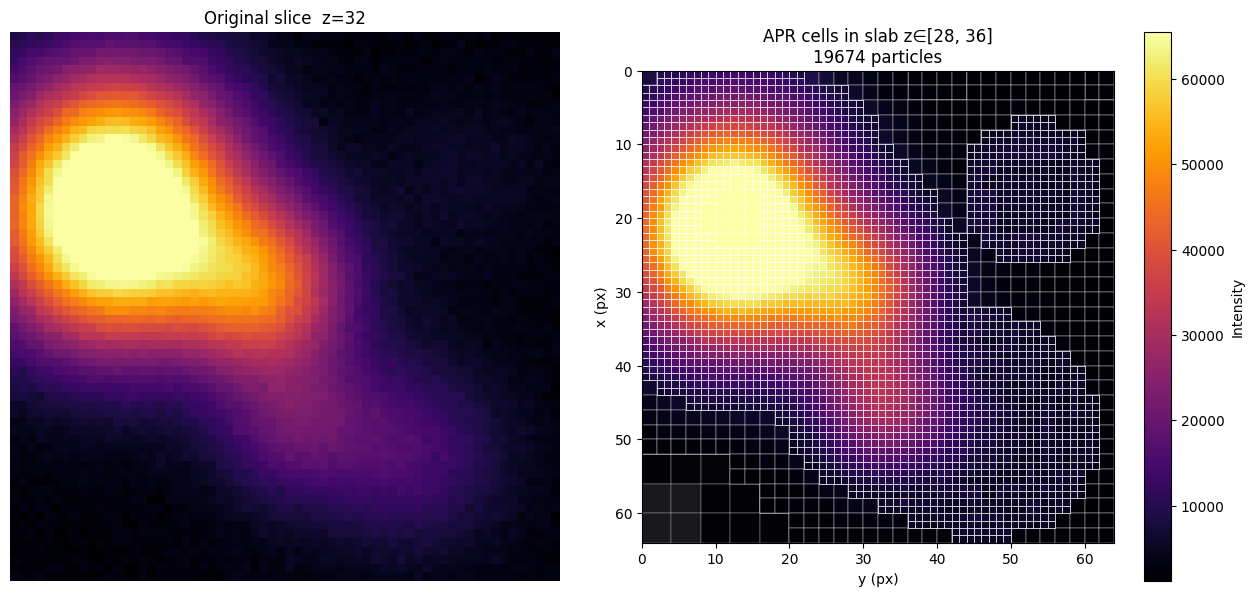

In [9]:
slab_z  = img.shape[0] // 2         # centre z-slice
slab_hw = 4                          # half-width in pixels

in_slab = np.abs(pz - slab_z) < slab_hw
s_z, s_x, s_y = pz[in_slab], px[in_slab], py[in_slab]
s_cs, s_int    = cell_size[in_slab], intensity[in_slab]

norm_i  = Normalize(vmin=s_int.min(), vmax=s_int.max())
cmap    = plt.cm.inferno

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: original image slice
axes[0].imshow(img[slab_z], cmap='inferno', origin='upper')
axes[0].set_title(f'Original slice  z={slab_z}')
axes[0].axis('off')

# Right: APR particles in slab drawn as squares
for (xc, yc, cs, intens) in zip(s_x, s_y, s_cs, s_int):
    rect = mpatches.Rectangle(
        (yc - cs/2, xc - cs/2), cs, cs,
        linewidth=max(0.2, 0.5 / cs),
        edgecolor='white',
        facecolor=cmap(norm_i(intens)),
        alpha=0.9,
    )
    axes[1].add_patch(rect)

axes[1].set_xlim(0, img.shape[2])
axes[1].set_ylim(img.shape[1], 0)
axes[1].set_aspect('equal')
axes[1].set_title(
    f'APR cells in slab z∈[{slab_z-slab_hw}, {slab_z+slab_hw}]\n'
    f'{in_slab.sum()} particles'
)
axes[1].set_xlabel('y (px)'); axes[1].set_ylabel('x (px)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_i)
plt.colorbar(sm, ax=axes[1], label='Intensity')
plt.tight_layout()
plt.show()

## 10. Intensity vs cell size — are bright regions always fine?

The APR places fine particles where **local information content** is high (edges, signal gradients), not simply where intensity is high.  This scatter shows the relationship.

/var/folders/v_/7mhfqnhs3d76987qq5hjcz2c0000gn/T/ipykernel_62662/791327081.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


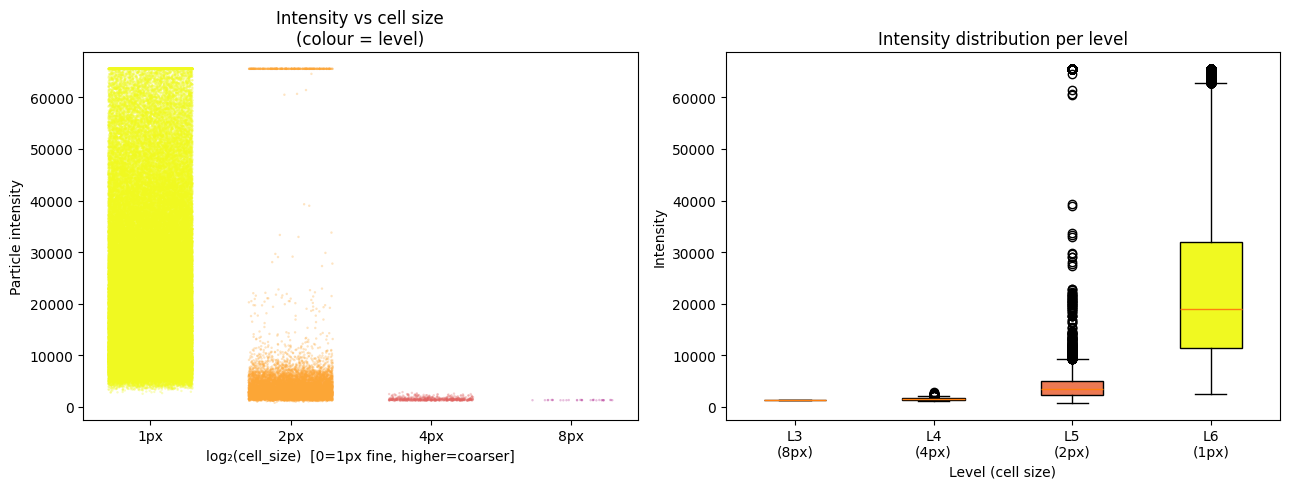

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: intensity vs cell_size, jitter cell_size for visibility
jitter = rng.uniform(-0.3, 0.3, len(pc))
axes[0].scatter(
    np.log2(cell_size) + jitter, intensity,
    c=level, cmap='plasma', norm=level_norm,
    s=3, alpha=0.3, linewidths=0,
)
axes[0].set_xlabel('log₂(cell_size)  [0=1px fine, higher=coarser]')
axes[0].set_ylabel('Particle intensity')
axes[0].set_title('Intensity vs cell size\n(colour = level)')
axes[0].set_xticks(range(int(np.log2(cell_size.min())), int(np.log2(cell_size.max())) + 1))
axes[0].set_xticklabels([f'{2**i}px' for i in axes[0].get_xticks()])

# Box plot: intensity distribution per level
data_per_level = [intensity[level == l] for l in unique_levels]
bp = axes[1].boxplot(
    data_per_level,
    labels=[f'L{l}\n({2**(level_max-l)}px)' for l in unique_levels],
    patch_artist=True,
)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_levels)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_xlabel('Level (cell size)')
axes[1].set_ylabel('Intensity')
axes[1].set_title('Intensity distribution per level')

plt.tight_layout()
plt.show()

## 11. Summary table

In [11]:
print(f"Image shape        : {img.shape}")
print(f"Total pixels       : {img.size:,}")
print(f"Total particles    : {len(pc):,}")
print(f"Compression ratio  : {img.size / len(pc):.2f}x")
print()
print("Point cloud columns:")
col_labels = ['z_center', 'x_center', 'y_center', 'intensity', 'cell_size', 'level']
for i, (label, col) in enumerate(zip(col_labels, pc.T)):
    print(f"  [{i}] {label:<12}  min={col.min():.1f}  max={col.max():.1f}  mean={col.mean():.1f}")
print()
print("Per-level breakdown:")
print(f"  {'Level':>6} {'cell_size':>10} {'N particles':>12} {'%':>6} {'mean intensity':>15}")
print('  ' + '-'*54)
for l in unique_levels:
    mask = level == l
    cs   = int(2 ** (level_max - l))
    n    = mask.sum()
    mi   = intensity[mask].mean()
    print(f"  {l:>6} {cs:>10}px {n:>12,} {100*n/len(pc):>5.1f}% {mi:>15.0f}")

Image shape        : (64, 64, 64)
Total pixels       : 262,144
Total particles    : 138,489
Compression ratio  : 1.89x

Point cloud columns:
  [0] z_center      min=0.5  max=63.5  mean=29.1
  [1] x_center      min=0.5  max=63.5  mean=31.9
  [2] y_center      min=0.5  max=63.5  mean=30.4
  [3] intensity     min=799.0  max=65535.0  mean=22168.2
  [4] cell_size     min=1.0  max=8.0  mean=1.1
  [5] level         min=3.0  max=6.0  mean=5.9

Per-level breakdown:
   Level  cell_size  N particles      %  mean intensity
  ------------------------------------------------------
       3          8px           31   0.0%            1325
       4          4px          606   0.4%            1551
       5          2px        9,948   7.2%            6092
       6          1px      127,904  92.4%           23521


## 12. Point cloud → APR and parts

Two complementary approaches depending on what you have available.

### Approach A — direct (original APR structure preserved)

`apr_to_pointcloud_3d` iterates the APR in a fixed, deterministic order, so row `i` of `pc`
always corresponds to particle index `i` in `parts`.  
If you still have the original `apr` object, you can rebuild `parts` from modified intensities
in one line — **no re-conversion needed, APR topology is unchanged**.

### Approach B — image reconstruction (APR structure not required)

Fill each particle's cubic cell back into a pixel volume, then call
`pyapr.converter.get_apr` on that volume.  
The resulting APR is re-computed from scratch, so the particle placement may differ slightly,
but the intensity information is fully preserved.

In [12]:
def pointcloud_to_parts(pc, apr):
    """Approach A: rebuild particle data from a point cloud using the original APR structure.

    The point cloud must have been produced by ``apr_to_pointcloud_3d`` for this ``apr``
    without any reordering — row i of ``pc`` maps to particle index i.

    Parameters
    ----------
    pc  : np.ndarray, shape (N, 6), float32
        Columns: z_center, x_center, y_center, intensity, cell_size, level
    apr : pyapr.APR
        The APR object the point cloud was extracted from.

    Returns
    -------
    apr   : pyapr.APR          (same object, unchanged)
    parts : pyapr.FloatParticles  (new particle data with intensities from pc)
    """
    assert len(pc) == apr.total_number_particles(), (
        f"Row count mismatch: pc has {len(pc)} rows but APR has "
        f"{apr.total_number_particles()} particles. "
        "Was the point cloud extracted from a different APR, or reordered?"
    )
    parts_new = pyapr.FloatParticles(pc[:, 3].astype(np.float32))
    return apr, parts_new


def pointcloud_to_image(pc, image_shape):
    """Convert a point cloud back to a pixel image by filling each particle's cell.

    Parameters
    ----------
    pc           : np.ndarray, shape (N, 6), float32
                   Columns: z_center, x_center, y_center, intensity, cell_size, level
    image_shape  : tuple (Z, X, Y)

    Returns
    -------
    image : np.ndarray, shape image_shape, float32
    """
    image = np.zeros(image_shape, dtype=np.float32)
    Z, X, Y = image_shape

    for zc, xc, yc, intens, cs, _ in pc:
        cs = int(cs)
        z0, z1 = int(zc - cs / 2), int(zc + cs / 2)
        x0, x1 = int(xc - cs / 2), int(xc + cs / 2)
        y0, y1 = int(yc - cs / 2), int(yc + cs / 2)
        # clamp to image bounds (defensive, shouldn't be needed for a well-formed APR)
        z0, z1 = max(z0, 0), min(z1, Z)
        x0, x1 = max(x0, 0), min(x1, X)
        y0, y1 = max(y0, 0), min(y1, Y)
        image[z0:z1, x0:x1, y0:y1] = intens

    return image


def pointcloud_to_apr(pc, image_shape, params=None):
    """Approach B: reconstruct a pixel image from the point cloud, then re-convert to APR.

    Parameters
    ----------
    pc           : np.ndarray, shape (N, 6), float32
    image_shape  : tuple (Z, X, Y)
    params       : pyapr.APRParameters or None (auto-parameters used if None)

    Returns
    -------
    apr   : pyapr.APR
    parts : pyapr.FloatParticles
    """
    recon_img = pointcloud_to_image(pc, image_shape)
    recon_u16 = np.clip(recon_img, 0, 65535).astype(np.uint16)
    return pyapr.converter.get_apr(recon_u16, params=params)


print("Functions defined:")
print("  pointcloud_to_parts(pc, apr)              → Approach A (direct, preserves APR topology)")
print("  pointcloud_to_image(pc, image_shape)      → fill pixel volume from cells")
print("  pointcloud_to_apr(pc, image_shape, params)→ Approach B (re-convert)")

Functions defined:
  pointcloud_to_parts(pc, apr)              → Approach A (direct, preserves APR topology)
  pointcloud_to_image(pc, image_shape)      → fill pixel volume from cells
  pointcloud_to_apr(pc, image_shape, params)→ Approach B (re-convert)


### Verify Approach A — round-trip intensity check

In [13]:
# ── Approach A ───────────────────────────────────────────────────────────────
apr_a, parts_a = pointcloud_to_parts(pc, apr)

# Reconstruct to pixel space and compare with the original reconstruction
recon_orig = pyapr.reconstruction.reconstruct_constant(apr, parts)
recon_a    = pyapr.reconstruction.reconstruct_constant(apr_a, parts_a)

diff_a = np.abs(recon_orig.astype(np.float32) - recon_a.astype(np.float32))

print("── Approach A (direct) ──────────────────────────────")
print(f"  Original APR particles : {apr.total_number_particles():,}")
print(f"  Rebuilt APR particles  : {apr_a.total_number_particles():,}  (same object)")
print(f"  Max pixel diff         : {diff_a.max():.4f}")
print(f"  Mean pixel diff        : {diff_a.mean():.6f}")
print(f"  Intensities identical  : {np.allclose(parts[:], parts_a[:])}")

── Approach A (direct) ──────────────────────────────
  Original APR particles : 138,489
  Rebuilt APR particles  : 138,489  (same object)
  Max pixel diff         : 0.0000
  Mean pixel diff        : 0.000000
  Intensities identical  : True


### Verify Approach B — image reconstruction then re-conversion

In [14]:
# ── Approach B ───────────────────────────────────────────────────────────────
print("Reconstructing pixel image from point cloud …")
recon_img = pointcloud_to_image(pc, img.shape)

print("Re-converting to APR …")
apr_b, parts_b = pointcloud_to_apr(pc, img.shape)

recon_b = pyapr.reconstruction.reconstruct_constant(apr_b, parts_b)
diff_b  = np.abs(recon_img - recon_b.astype(np.float32))

print()
print("── Approach B (image reconstruction + re-convert) ───")
print(f"  Re-converted APR particles : {apr_b.total_number_particles():,}")
print(f"  Original APR particles     : {apr.total_number_particles():,}")
print(f"  Max pixel diff (recon_img vs recon_b) : {diff_b.max():.4f}")
print(f"  Mean pixel diff                       : {diff_b.mean():.6f}")

Reconstructing pixel image from point cloud …
Re-converting to APR …

── Approach B (image reconstruction + re-convert) ───
  Re-converted APR particles : 139,966
  Original APR particles     : 138,489
  Max pixel diff (recon_img vs recon_b) : 1925.0000
  Mean pixel diff                       : 0.060265


### Visual comparison — all three at the same Z slice

/var/folders/v_/7mhfqnhs3d76987qq5hjcz2c0000gn/T/ipykernel_62662/1826007164.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


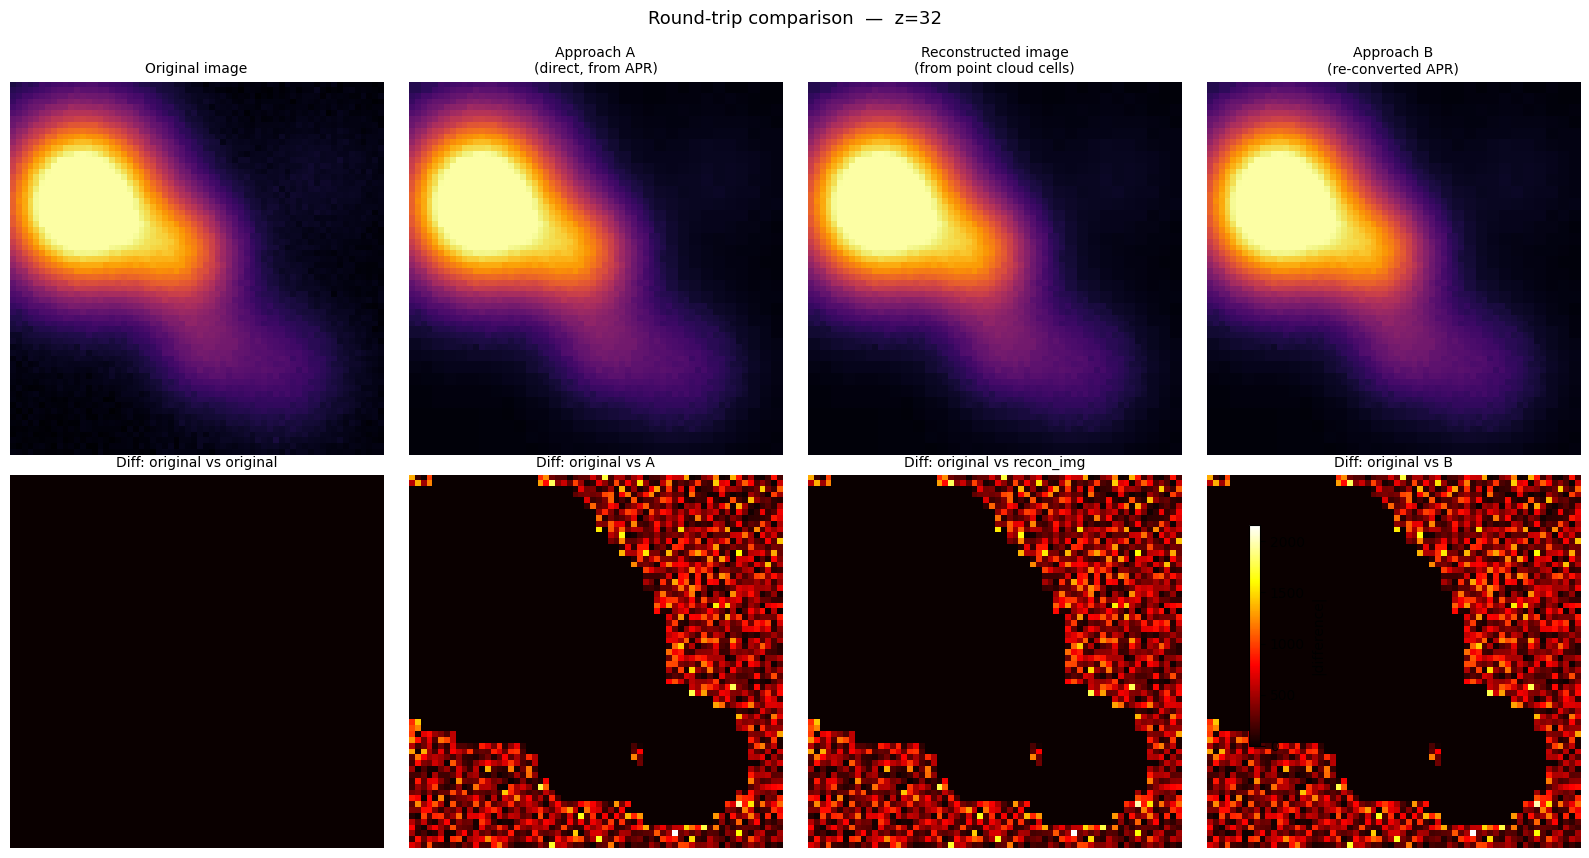

In [15]:
z = img.shape[0] // 2

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

slices = [
    (img[z],              'Original image'),
    (recon_orig[z],       'Approach A\n(direct, from APR)'),
    (recon_img[z],        'Reconstructed image\n(from point cloud cells)'),
    (recon_b[z],          'Approach B\n(re-converted APR)'),
]

vmin = min(s.min() for s, _ in slices)
vmax = max(s.max() for s, _ in slices)

for ax, (sl, title) in zip(axes[0], slices):
    ax.imshow(sl, cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Difference maps (vs original image)
diff_slices = [
    (np.zeros_like(img[z], dtype=np.float32),                        'Diff: original vs original'),
    (np.abs(img[z].astype(np.float32) - recon_a[z].astype(float)),   'Diff: original vs A'),
    (np.abs(img[z].astype(np.float32) - recon_img[z]),               'Diff: original vs recon_img'),
    (np.abs(img[z].astype(np.float32) - recon_b[z].astype(float)),   'Diff: original vs B'),
]

dmax = max(d.max() for d, _ in diff_slices[1:])
for ax, (dl, title) in zip(axes[1], diff_slices):
    im = ax.imshow(dl, cmap='hot', vmin=0, vmax=dmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.colorbar(im, ax=axes[1].tolist(), label='|difference|', shrink=0.7)
plt.suptitle(f'Round-trip comparison  —  z={z}', fontsize=13)
plt.tight_layout()
plt.show()